In [ ]:
import json
with open("results/sgd_results_lrs.json", "r") as f:
    sgd_results_lrs = json.load(f)
with open("results/adam_results_lrs.json", "r") as f:
    adam_results_lrs = json.load(f)
with open("results/olnm_results_lrs.json", "r") as f:
    olnm_results_lrs = json.load(f)


In [ ]:
sgd_results_lrs = {k: sgd_results_lrs[k] for k in sorted(sgd_results_lrs.keys())}
adam_results_lrs = {k: adam_results_lrs[k] for k in sorted(adam_results_lrs.keys())}
olnm_results_lrs = {k: olnm_results_lrs[k] for k in sorted(olnm_results_lrs.keys())}

In [60]:
import numpy as np
def smooth_history(history, window_size=2):
    history = np.array(history)
    kernel = np.ones(window_size) / window_size
    smoothed = np.convolve(history, kernel, mode='valid')
    pad = (window_size - 1) // 2
    return np.pad(smoothed, (pad, window_size - 1 - pad), mode='edge')

# --- Comparison Plot ---
def comparison_plot(results_lrs):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 6))
    plt.rcParams['font.family'] = 'Helvetica'
    for key in results_lrs.keys():
        plt.plot(smooth_history(results_lrs[key]['train_losses']), 
                alpha=0.8, 
                linewidth=1., 
                linestyle='--',
                label=f'{key}', 
                markevery=5, marker='*')

    plt.xlabel('Epochs', fontsize=16)
    plt.xticks(fontsize=16)

    plt.ylabel('LCE Training Loss', fontsize=16)
    plt.yticks(fontsize=16)

    plt.legend(loc='upper right', fontsize=16)
    plt.grid(True, alpha=0.5)
    plt.show()

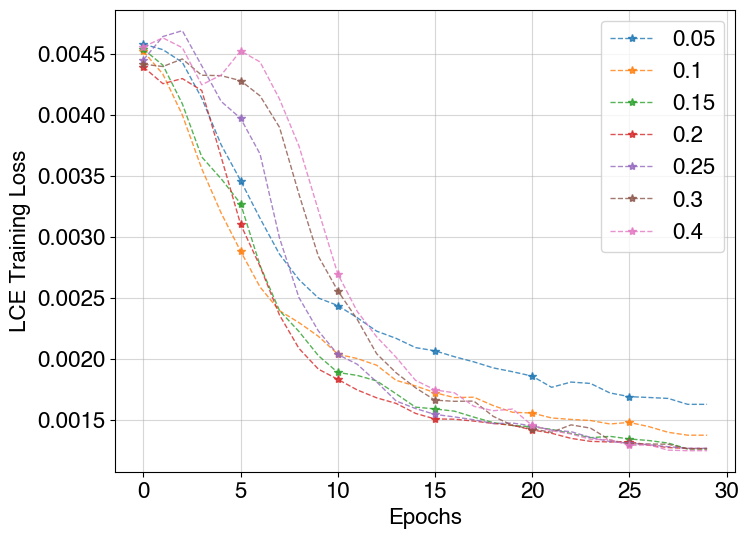

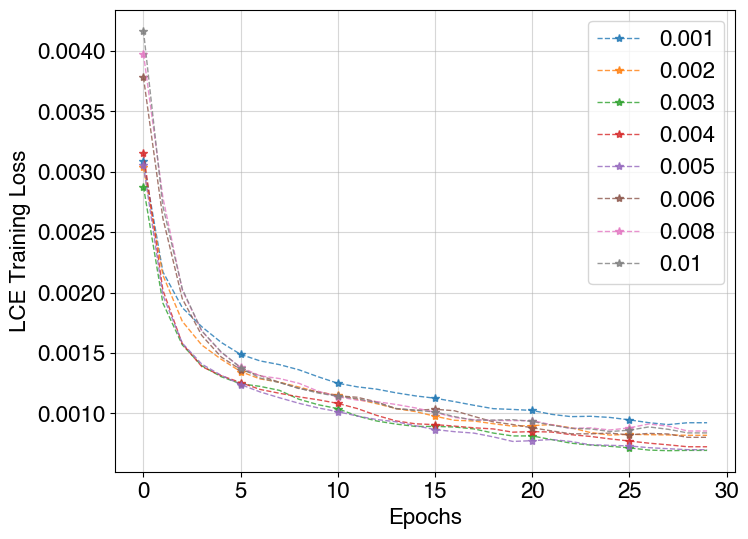

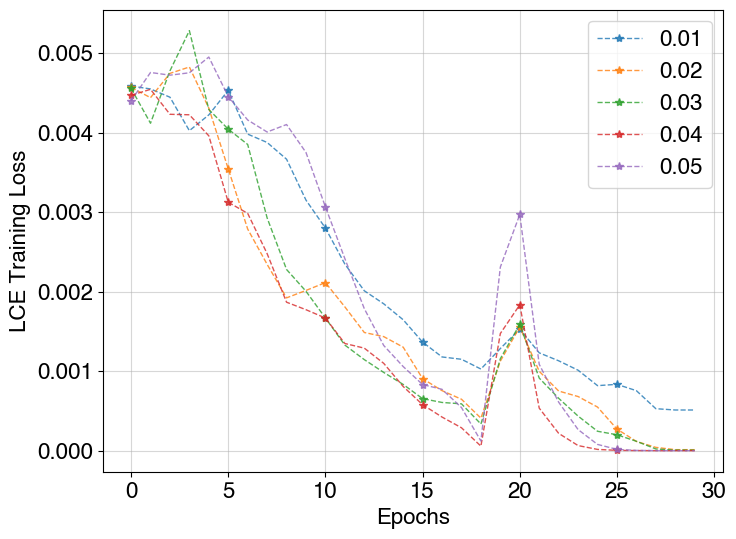

In [66]:
comparison_plot(sgd_results_lrs)
comparison_plot(adam_results_lrs)
comparison_plot(olnm_results_lrs)

## Seed Comparison

In [ ]:
import json
with open("results/fashion_results_olnm_42.json", "r") as f:
    olnm_42 = json.load(f)
olnm_42.pop('SGD')
with open("results/fashion_results_olnm_123.json", "r") as f:
    olnm_123 = json.load(f)
with open("results/fashion_results_olnm_692.json", "r") as f:
    olnm_692 = json.load(f)
with open("results/fashion_results_olnm_989.json", "r") as f:
    olnm_989 = json.load(f)
with open("results/fashion_results_olnm_22.json", "r") as f:
    olnm_22 = json.load(f)

In [5]:
# Change the key to 'SGD'
olnm_123['OLNM 123'] = olnm_123.pop('OLNM')
olnm_42['OLNM 42'] = olnm_42.pop('OLNM')
olnm_692['OLNM 692'] = olnm_692.pop('OLNM')
olnm_989['OLNM 989'] = olnm_989.pop('OLNM')
olnm_22['OLNM 22'] = olnm_22.pop('OLNM')

all_results = {**olnm_42, **olnm_123, **olnm_692, **olnm_989, **olnm_22}
all_results.keys()

dict_keys(['OLNM 42', 'OLNM 123', 'OLNM 692', 'OLNM 989', 'OLNM 22'])

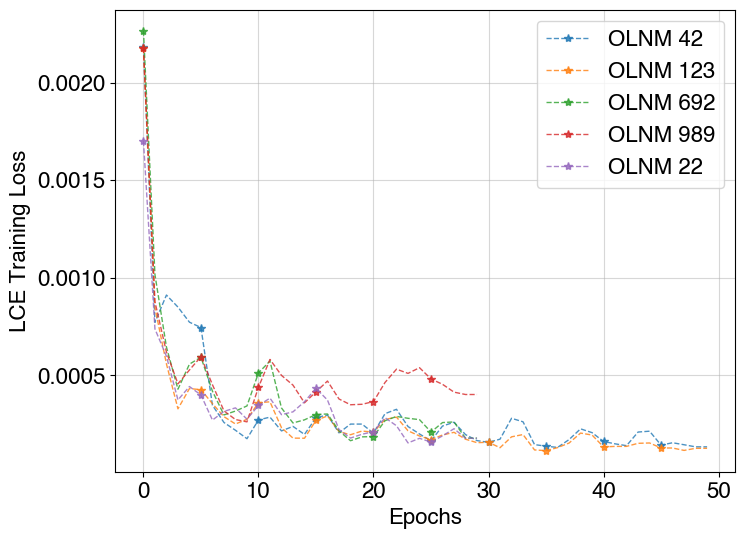

In [6]:
import numpy as np
def smooth_history(history, window_size=2):
      history = np.array(history)
      kernel = np.ones(window_size) / window_size
      smoothed = np.convolve(history, kernel, mode='valid')
      pad = (window_size - 1) // 2
      return np.pad(smoothed, (pad, window_size - 1 - pad), mode='edge')

# --- Comparison Plot ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.rcParams['font.family'] = 'Helvetica'
for key in all_results.keys():
    plt.plot(smooth_history(all_results[key][0]), 
            alpha=0.8, 
            linewidth=1., 
            linestyle='--',
            label=f'{key}', 
            markevery=5, marker='*')

plt.xlabel('Epochs', fontsize=16)
plt.xticks(fontsize=16)

plt.ylabel('LCE Training Loss', fontsize=16)
plt.yticks(fontsize=16)

plt.legend(loc='upper right', fontsize=16)
plt.grid(True, alpha=0.5)
plt.show()